In [11]:
!pip install langgraph

In [17]:
# execute the graph
intial_state = {'weight_kg':80, 'height_m':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


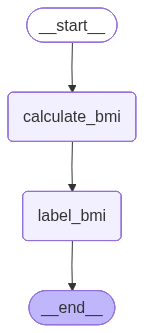

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [19]:
# define state
class ADD(TypedDict):

    a: float
    b: float
    c: float
    zpn: str

In [20]:
def calculate_add(state: ADD) -> ADD:

    a = state['a']
    b = state['b']



    state['c'] = a+b

    return state

In [30]:
def zpn(state: ADD) -> ADD:

    c = state['c']

    if c < 0:
        state['zpn'] = "negative"
    elif c > 0:
        state['zpn'] = "positive"
    else:
        state['zpn'] = "zero"

    return state

In [31]:
graph = StateGraph(ADD)

# add nodes to your graph
graph.add_node('addition', calculate_add)
graph.add_node('zero_positive_negative',zpn )

# add edges to your graph
graph.add_edge(START, 'addition')
graph.add_edge('addition', 'zero_positive_negative')
graph.add_edge('zero_positive_negative', END)


# compile the graph
workflow = graph.compile()

In [33]:
# execute the graph
intial_state = {'a':-12, 'b':0}

final_state = workflow.invoke(intial_state)

print(final_state)

{'a': -12, 'b': 0, 'c': -12, 'zpn': 'negative'}


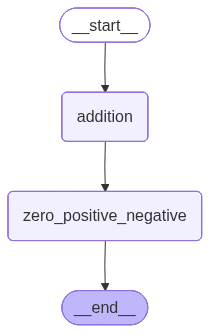

In [29]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

## LLM based workflow

In [34]:
!pip install -q langchain-groq

In [38]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages

In [52]:
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)

In [53]:
class LLMState(TypedDict):

    question: str
    answer: str

In [54]:
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

In [55]:
# create our graph

graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()

In [56]:
# execute

intial_state = {'question': 'tell me the water crise due to data center?'}

final_state = workflow.invoke(intial_state)

print(final_state['answer'])

The water crisis due to data centers is a growing concern. Data centers, which are large facilities that house servers and store data for various industries, require significant amounts of water to operate. Here are some key facts about the water crisis caused by data centers:

**Why do data centers need water?**

1. **Cooling systems**: Data centers use water to cool their servers and other equipment. This is done through various methods, including evaporative cooling, where water is used to absorb heat from the air.
2. **Humidity control**: Data centers need to maintain a stable humidity level to prevent damage to equipment. Water is used to control humidity levels.
3. **Fire suppression**: Some data centers use water-based fire suppression systems to protect equipment in case of a fire.

**The impact of data centers on water resources**

1. **Water usage**: A single data center can use up to 1 million gallons of water per day, which is equivalent to the water usage of a small city.
